# Ejercicio 12: Multimodal Embeddings

**Nombre:** Bautista Alexis  
**Fecha:** 13 de julio de 2026

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

## Pasos:

### 1. Obtener embeddings de imágenes y textos con CLIP.

In [2]:
import torch
from PIL import Image
import requests
from transformers import CLIPProcessor, CLIPModel

# Cargar el modelo preentrenado y su procesador
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)

# Definir textos de prueba y cargar algunas imágenes
textos = [
    "un perro Beagle corriendo en el césped", 
    "un gato durmiendo", 
    "un auto en la calle"
]

# Uso una imagen de un perro Beagle de ejemplo
url = "https://images.unsplash.com/photo-1537151608828-ea2b11777ee8?q=80&w=400&auto=format&fit=crop"
imagen = Image.open(requests.get(url, stream=True).raw)

# Procesar los inputs (tokenización de texto y preprocesamiento de imagen)
inputs = processor(
    text=textos, 
    images=imagen, 
    return_tensors="pt", 
    padding=True
)

# Pasar los inputs por el modelo para extraer los embeddings
with torch.no_grad():
    image_features = model.get_image_features(pixel_values=inputs.pixel_values)
    text_features = model.get_text_features(input_ids=inputs.input_ids, attention_mask=inputs.attention_mask)

# Extraer los tensores pooled de los objetos BaseModelOutputWithPooling
image_embeddings = image_features.pooler_output
text_embeddings = text_features.pooler_output

# Imprimir las dimensiones para verificar
print(f"Dimensión del embedding de la imagen: {image_embeddings.shape}")
print(f"Dimensión del embedding de los textos: {text_embeddings.shape}")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 15083.88it/s]


Dimensión del embedding de la imagen: torch.Size([1, 512])
Dimensión del embedding de los textos: torch.Size([3, 512])


### 2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).

In [4]:
import torch.nn.functional as F

# Comprobar que comparten la misma dimensionalidad
print("--- Verificación de Dimensiones ---")
dim_imagen = image_embeddings.shape[1]
dim_textos = text_embeddings.shape[1]
print(f"Dimensiones de la imagen: {dim_imagen}")
print(f"Dimensiones de los textos: {dim_textos}")
print(f"¿Tienen la misma dimensión?: {dim_imagen == dim_textos}")

# Normalizar los vectores (L2 Normalization)
# CLIP requiere que los vectores estén normalizados para que la magnitud no afecte el cálculo de la similitud del coseno.
image_features_norm = F.normalize(image_embeddings, p=2, dim=-1)
text_features_norm = F.normalize(text_embeddings, p=2, dim=-1)

# Demostrar que son comparables (Similitud del Coseno)
print("\n--- Comparabilidad (Similitud del Coseno) ---")
# Realizamos el producto punto entre la imagen y los textos.
# Al estar normalizados, el producto punto equivale a la similitud del coseno.
similarities = torch.matmul(image_features_norm, text_features_norm.T)

# Imprimir el nivel de coincidencia entre la imagen y cada frase
for i, texto in enumerate(textos):
    similitud = similarities[0, i].item()
    print(f"Similitud con '{texto}': {similitud:.4f}")

--- Verificación de Dimensiones ---
Dimensiones de la imagen: 512
Dimensiones de los textos: 512
¿Tienen la misma dimensión?: True

--- Comparabilidad (Similitud del Coseno) ---
Similitud con 'un perro Beagle corriendo en el césped': 0.1926
Similitud con 'un gato durmiendo': 0.1689
Similitud con 'un auto en la calle': 0.1583


- La similitud más alta (0.1926) corresponde a la frase del perro Beagle. Esto prueba que en ese espacio de 512 dimensiones, el vector de la imagen y el vector del texto correcto apuntan hacia la misma dirección.

- El gato obtiene un puntaje intermedio (0.1689); porque sigue siendo un animal y una mascota, por lo que comparte atributos con el perro. Por el contrario, el auto obtiene el puntaje más bajo (0.1583) al ser un concepto inanimado y semánticamente muy alejado.

### 3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.

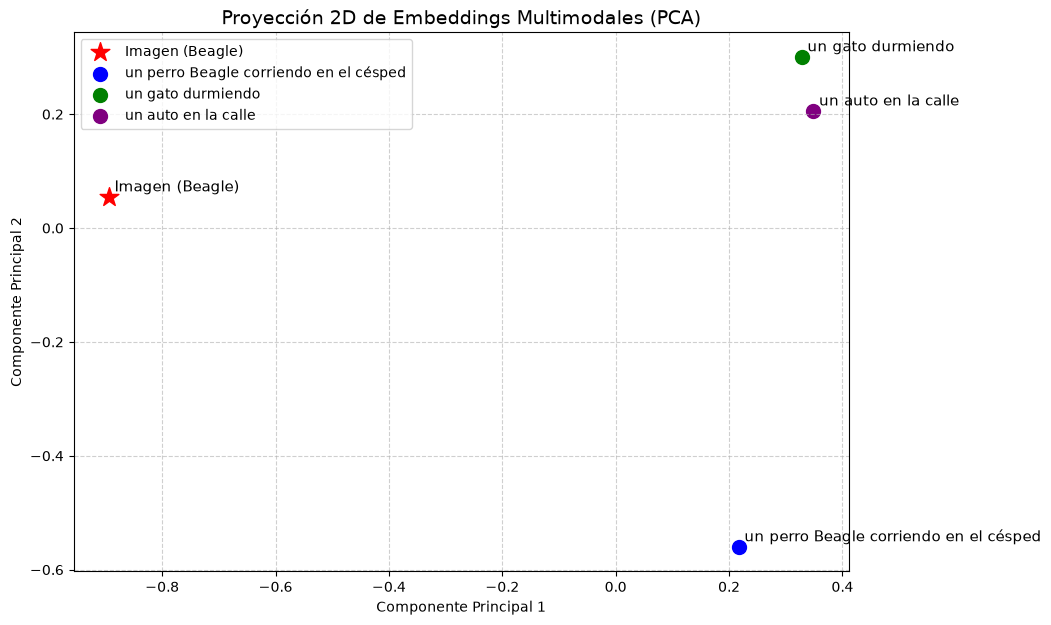

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Junto todos los vectores normalizados en una sola matriz
# image_features_norm tiene tamaño (1, 512), text_features_norm tiene (3, 512)
todos_los_vectores = torch.cat([image_features_norm, text_features_norm], dim=0).numpy()

etiquetas = ["Imagen (Beagle)"] + textos

# Reducir de 512 a 2 dimensiones usando PCA
pca = PCA(n_components=2)
vectores_2d = pca.fit_transform(todos_los_vectores)

# Configurar el gráfico
plt.figure(figsize=(10, 7))
colores = ['red', 'blue', 'green', 'purple']
marcadores = ['*', 'o', 'o', 'o'] # Estrella para la imagen, círculos para el texto

# Graficar cada punto iterando sobre la matriz 2D
for i in range(len(vectores_2d)):
    plt.scatter(
        vectores_2d[i, 0], 
        vectores_2d[i, 1], 
        c=colores[i], 
        marker=marcadores[i],
        s=200 if i == 0 else 100,
        label=etiquetas[i]
    )
    # Agregar el texto al lado de cada punto
    plt.text(vectores_2d[i, 0] + 0.01, vectores_2d[i, 1] + 0.01, etiquetas[i], fontsize=11)

plt.title("Proyección 2D de Embeddings Multimodales (PCA)", fontsize=14)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

In [12]:
import torch
import requests
from PIL import Image
import torch.nn.functional as F

# Cargar múltiples imágenes para tener un "corpus" visual
urls = [
    "https://images.unsplash.com/photo-1537151608828-ea2b11777ee8?q=80&w=400", # Perro
    "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?q=80&w=400", # Gato
    "https://images.unsplash.com/photo-1494976388531-d1058494cdd8?q=80&w=400"  # Auto
]

imagenes = [Image.open(requests.get(url, stream=True).raw) for url in urls]

# textos = ["un perro Beagle corriendo en el césped", "un gato durmiendo", "un auto en la calle"]

# Procesar todo en lote (batch)
inputs = processor(
    text=textos, 
    images=imagenes, 
    return_tensors="pt", 
    padding=True
)

with torch.no_grad():
    image_features = model.get_image_features(pixel_values=inputs.pixel_values)
    text_features = model.get_text_features(input_ids=inputs.input_ids, attention_mask=inputs.attention_mask)

# Extraer pooled outputs y Normalizar
image_embeddings = image_features.pooler_output
text_embeddings = text_features.pooler_output

# Calcular matriz de similitudes (Imágenes x Textos)
# El resultado es una matriz de 3x3
similarity_matrix = torch.matmul(image_features_norm, text_features_norm.T)

print("--- BÚSQUEDA IMAGEN -> TEXTO (Clasificación Zero-Shot) ---")
# Por cada imagen (filas), buscamos el índice del texto con el valor más alto
mejores_textos_idx = similarity_matrix.argmax(dim=1)

for i in range(len(imagenes)):
    mejor_texto = textos[mejores_textos_idx[i].item()]
    puntaje = similarity_matrix[i, mejores_textos_idx[i]].item()
    print(f"Imagen {i+1} emparejada con: '{mejor_texto}' (Similitud: {puntaje:.4f})")

print("\n--- BÚSQUEDA TEXTO -> IMAGEN (Recuperación de Imágenes) ---")
# Por cada texto (columnas), buscamos el índice de la imagen con el valor más alto
mejores_imagenes_idx = similarity_matrix.argmax(dim=0)

for i in range(len(textos)):
    mejor_imagen = mejores_imagenes_idx[i].item() + 1
    puntaje = similarity_matrix[mejores_imagenes_idx[i], i].item()
    print(f"Texto '{textos[i]}' emparejado con: Imagen {mejor_imagen} (Similitud: {puntaje:.4f})")

--- BÚSQUEDA IMAGEN -> TEXTO (Clasificación Zero-Shot) ---
Imagen 1 emparejada con: 'un perro Beagle corriendo en el césped' (Similitud: 0.1926)
Imagen 2 emparejada con: 'un gato durmiendo' (Similitud: 0.2611)
Imagen 3 emparejada con: 'un auto en la calle' (Similitud: 0.1835)

--- BÚSQUEDA TEXTO -> IMAGEN (Recuperación de Imágenes) ---
Texto 'un perro Beagle corriendo en el césped' emparejado con: Imagen 1 (Similitud: 0.1926)
Texto 'un gato durmiendo' emparejado con: Imagen 2 (Similitud: 0.2611)
Texto 'un auto en la calle' emparejado con: Imagen 3 (Similitud: 0.1835)
